## 19.3. Asynchronous Random Search

!note need to change randint seed if use Windows System

In [1]:
import logging
from d2l import torch as d2l

logging.basicConfig(level=logging.INFO)
from syne_tune import StoppingCriterion, Tuner
from syne_tune.backend.python_backend import PythonBackend
from syne_tune.config_space import loguniform, randint
from syne_tune.experiments import load_experiment
from syne_tune.optimizer.baselines import RandomSearch

INFO:root:SageMakerBackend is not imported since dependencies are missing. You can install them with
   pip install 'syne-tune[extra]'


AWS dependencies are not imported since dependencies are missing. You can install them with
   pip install 'syne-tune[aws]'
or (for everything)
   pip install 'syne-tune[extra]'
AWS dependencies are not imported since dependencies are missing. You can install them with
   pip install 'syne-tune[aws]'
or (for everything)
   pip install 'syne-tune[extra]'


INFO:root:Ray Tune schedulers and searchers are not imported since dependencies are missing. You can install them with
   pip install 'syne-tune[raytune]'
or (for everything)
   pip install 'syne-tune[extra]'


### 19.3.1. Objective Function

In [2]:
def hpo_objective_lenet_synetune(learning_rate, batch_size, max_epochs):
  from syne_tune import Reporter
  from d2l import torch as d2l

  model = d2l.LeNet(lr=learning_rate, num_classes=10)
  trainer = d2l.HPOTrainer(max_epochs=1, num_gpus=1)
  data = d2l.FashionMNIST(batch_size=batch_size)
  model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
  report = Reporter()
  for epoch in range(1, max_epochs + 1):
    if epoch == 1:
      # Initialize the state of Trainer
      trainer.fit(model=model, data=data)
    else:
      trainer.fit_epoch()
    validation_error = trainer.validation_error().cpu().detach().numpy()
    report(epoch=epoch, validation_error=float(validation_error))

### 19.3.2 Asynchronous Scheduler

In [3]:
n_workers = 2  # Needs to be <= the number of available GPUs

max_wallclock_time = 12 * 60  # 12 minutes

In [4]:
mode = "min"
metric = "validation_error"

In [5]:
config_space = {
  "learning_rate": loguniform(1e-2, 1),
  "batch_size": randint(32, 256),
  "max_epochs": 10,
}
initial_config = {
  "learning_rate": 0.1,
  "batch_size": 128,
}

In [6]:
trial_backend = PythonBackend(
  tune_function=hpo_objective_lenet_synetune,
  config_space=config_space,
)

In [7]:
scheduler = RandomSearch(
    config_space,
    metric=metric,
    mode=mode,
    points_to_evaluate=[initial_config],
)

INFO:syne_tune.optimizer.schedulers.fifo:max_resource_level = 10, as inferred from config_space
INFO:syne_tune.optimizer.schedulers.fifo:Master random_seed = 1429490969


In [8]:
stop_criterion = StoppingCriterion(max_wallclock_time=max_wallclock_time)

tuner = Tuner(
  trial_backend=trial_backend,
  scheduler=scheduler,
  stop_criterion=stop_criterion,
  n_workers=n_workers,
  print_update_interval=int(max_wallclock_time * 0.6)
)

In [9]:
tuner.run()

INFO:syne_tune.tuner:results of trials will be saved on C:\Users\fanyu\syne-tune\python-entrypoint-2025-02-11-05-36-25-515
INFO:root:Detected 1 GPUs
INFO:root:running subprocess with command: c:\Users\fanyu\miniconda3\envs\d2l2\python.exe c:\Users\fanyu\miniconda3\envs\d2l2\lib\site-packages\syne_tune\backend\python_backend\python_entrypoint.py --learning_rate 0.1 --batch_size 128 --max_epochs 10 --tune_function_root C:\Users\fanyu\syne-tune\python-entrypoint-2025-02-11-05-36-25-515\tune_function --tune_function_hash 57cc0de8650b77d8d750bc5983fd60ae --st_checkpoint_dir C:\Users\fanyu\syne-tune\python-entrypoint-2025-02-11-05-36-25-515\0\checkpoints
INFO:syne_tune.tuner:(trial 0) - scheduled config {'learning_rate': 0.1, 'batch_size': 128, 'max_epochs': 10}
INFO:root:running subprocess with command: c:\Users\fanyu\miniconda3\envs\d2l2\python.exe c:\Users\fanyu\miniconda3\envs\d2l2\lib\site-packages\syne_tune\backend\python_backend\python_entrypoint.py --learning_rate 0.22247702834826782

--------------------
Resource summary (last result is reported):
 trial_id     status  iter  learning_rate  batch_size  max_epochs  epoch  validation_error  worker-time
        0  Completed    10       0.100000         128          10     10          0.284909   290.202366
        1  Completed    10       0.222477         229          10     10          0.470899   297.060329
        2  Completed    10       0.296575         247          10     10          0.241682   273.959984
        3  Completed    10       0.010219          67          10     10          0.900205   278.932769
        4 InProgress     3       0.332521         202          10      3          0.552180    85.290702
        5 InProgress     3       0.012853         115          10      3          0.899986    85.317535
2 trials running, 4 finished (4 until the end), 720.10s wallclock-time

validation_error: best 0.24168241024017334 for trial-id 2
--------------------


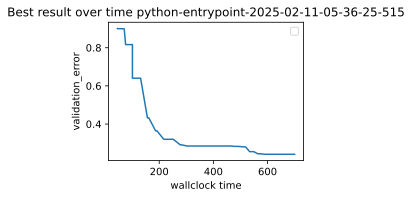

In [10]:
d2l.set_figsize()
tuning_experiment = load_experiment(tuner.name)
tuning_experiment.plot()

### 19.3.3. Visualize the Asynchronoous Optimization Process

Text(0, 0.5, 'objective function')

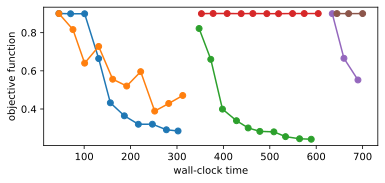

In [11]:
d2l.set_figsize([6, 2.5])
results = tuning_experiment.results

for trial_id in results.trial_id.unique():
  df = results[results["trial_id"] == trial_id]
  d2l.plt.plot(
    df["st_tuner_time"],
    df["validation_error"],
    marker="o"
  )
  
d2l.plt.xlabel("wall-clock time")
d2l.plt.ylabel("objective function")